In [101]:

# NOTE
# Use training, test, validation sets (done)

# Apply VQVAE

In [102]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split
from torchmetrics.regression import MeanSquaredError
from matplotlib.gridspec import GridSpec

In [103]:
# References
# https://datatas.com/how-to-use-variational-autoencoders-for-large-scale-data-compression/

In [104]:
# Task:
# Create plot with train loss, test loss, valid loss
# Plots with different betas
# Check what error curves are good for VAE
# Plot before and after plots

In [105]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25

In [106]:
def show_image(events: np.array) -> None:
    image_plot = events.to_images()[0][1]
    plt.imshow(image_plot, cmap='gist_yarg', origin='lower')
    plt.show()
    
def _tensor_to_numpy(values: torch.Tensor) -> np.array:
    return values.cpu().detach().numpy()

def plot_patch(patch: np.array, title: str) -> None:
    plt.imshow(patch, cmap='gist_yarg', origin='lower')
    plt.title(title)
    plt.show()
    
def _get_encoded_patch_bits(encoded_size,
                           patch_size,
                           module_rows=160,
                           module_cols=416):
    
    encoded_width, encoded_height, num_embeddings = encoded_size
    # print(encoded_width, encoded_height, np.log2(num_embeddings))
    vq_bits = encoded_width * encoded_height * np.log2(num_embeddings)
    
    # Patch address bits
    bits_patch_row = np.ceil(np.log2(np.ceil(module_rows / patch_size)))
    bits_patch_col = np.ceil(np.log2(np.ceil(module_cols / patch_size)))
    total = bits_patch_row + bits_patch_col + vq_bits
    
    # 267 % 256 = 11
    return total.astype(np.uint8)

def _get_total_hit_bits(total_hits: int) -> int:
    
    # Patch address bits
    return total_hits * BITS_HIT

def _get_total_patch_bits(patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> int:
    encoded_patch_bits = _get_encoded_patch_bits(encoded_patch_size, patch_size)
    return np.uint64(patch_amount * encoded_patch_bits)

def _get_compression_ratio(n_hits_total: int, patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> float:
    total_bits = _get_total_hit_bits(n_hits_total)
    
    total_patch_bits = _get_total_patch_bits(
        patch_amount, 
        encoded_patch_size, 
        patch_size
    )
    return total_bits / total_patch_bits

def _get_patch_count(event: PixelDigiEvent) -> int:
    event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
    # event_patches_adcs = [
    #     event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
    #     for event_patch_flat in event_patches_adcs_flat
    # ]
    return len(event_patches_adcs_flat)
    
# helper function
def _display_gradients(model: object) -> None:
    print("Showing model gradients")
    for name, param in model.named_parameters():
        if param.grad is not None:
            print(name, param.grad.norm().item())
            
def plot_metric_results(
    y_values: list[float], 
    x_values: int, 
    y_title: str, 
    title: str,
    x_label: str,
    marker: str=None
) -> None:
    print(title + " values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, marker=marker)
    plt.xlabel(x_label)
    plt.ylabel(y_title)
    plt.legend()
    plt.title(title)
    plt.show()

In [107]:
def _get_compression_ratio_vae(n_hits_total: int, patch_amount: int, z: torch.tensor) -> float:
    total_hit_bits = _get_total_hit_bits(n_hits_total)    
    z_item_amount = z[0][0].numel()  
    
    # get byte size per element in latent vector 2 x 2 
    z_bytes_per_element = z.element_size()  
    z_total_bytes = z_item_amount * z_bytes_per_element 
    
    # patch size to bits
    z_1sp_total_bits = z_total_bytes * 8
    
    # total patch size
    total_encoded_patch_bits = patch_amount * z_1sp_total_bits
    ratio = total_hit_bits / total_encoded_patch_bits    
    
    return {
        "compression_ratio" : ratio,
        "total_hits" : n_hits_total,
        "total_hit_bits" : total_hit_bits,
        "total_patch_amount" : patch_amount,
        "encoded_patch_bits" : z_1sp_total_bits,
        "total_encoded_patch_bits" : total_encoded_patch_bits,
    }

In [108]:
# Loading data

pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:03<00:00, 281.66it/s]


In [109]:
batch_size = 64
# beta = 0
beta = 1e-5
learning_rate = 1e-3
num_epochs = 80
channels = 1
latent_dim = 16
num_embeddings = 128

# logs
LOG_EVERY = 10


In [110]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [111]:
mse = MeanSquaredError()
mse = mse.to(device)

In [112]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [113]:
event_train = events_train[:SELECTED_EVENTS][0]

In [114]:
patch_amount = _get_patch_count(event_train)
total_hit_amount = len(event_train)

print(f"Total patch amount: {patch_amount}")
print(f"Total hits: {total_hit_amount}")

Total patch amount: 15857
Total hits: 48169


In [115]:
class PixelPatchesDataset(torch.utils.data.Dataset):
    def __init__(self, event: PixelDigiEvent, transform=None):
        event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
        self.event_patches_adcs = [
            event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
            for event_patch_flat in event_patches_adcs_flat
            if not (np.all(event_patch_flat == 0))
        ]
        
        self.transform = transform

    # Defining the length of the dataset
    def __len__(self) -> int:
        return len(self.event_patches_adcs)

    # Defining the method to get an item from the dataset
    def __getitem__(self, index: int) -> np.array:
        # print(self.event_patches_adcs[index])
        event_patch = self.event_patches_adcs[index]
        
        # Applying the transform
        if self.transform:
            event_patch = self.transform(event_patch)
            # print(event_patch)
        
        return event_patch

In [116]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
])

event_dataset = PixelPatchesDataset(event_train, transform)
dataset_size = len(event_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, val_size, test_size]
)

# # Training data prepearation

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size,
    shuffle=False
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")


# EXAMPLE with events test
# train_loader = DataLoader(
#     dataset=event_dataset, 
#     batch_size=batch_size
# )

# # Test data preparation
# events_test_loaders = []
# for event_test in events_test:
#     event_dataset = PixelPatchesDataset(event_test, transform)

#     event_test_loader = DataLoader(
#         dataset=event_dataset, 
#         batch_size=batch_size
#     )
#     events_test_loaders.append(event_test_loader)

Training set size: 12685
Validation set size: 1585
Test set size: 1587


In [117]:
# def _get_vae_loss(
#     recon_x: torch.tensor, 
#     x: torch.tensor, 
#     mu: torch.tensor, 
#     logvar: torch.tensor
# ) -> float:
#     recon_loss = F.binary_cross_entropy(recon_x, x, reduction="mean")
    
#     # KL_divergence
#     kl_loss = -0.5 * (
#         1 + logvar - mu.pow(2) - logvar.exp()
#     )
    
#     kl_loss = kl_loss.mean()
    
#     return (
#         recon_loss + beta * kl_loss,
#         recon_loss,
#         beta,
#         kl_loss
#     )

def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor
) -> float:
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="mean")
    return recon_loss
    # # KL_divergence
    # kl_loss = -0.5 * (
    #     1 + logvar - mu.pow(2) - logvar.exp()
    # )
    
    # kl_loss = kl_loss.mean()
    
    # return (
    #     recon_loss + beta * kl_loss,
    #     recon_loss,
    #     beta,
    #     kl_loss
    # )

In [118]:
# TODO: https://www.wgilpin.com/cphy/vq-vae/
# TODO: thoroughly analyze
# >> a = a.unsqueeze(1)
# >>> a
# tensor([[[[7.8000, 9.6000],
#           [1.2000, 3.6000]]],


#         [[[7.6000, 3.0500],
#           [1.0500, 6.7000]]]])
# >>> a.shape
# torch.Size([2, 1, 2, 2])
# >>> a = a.permute(0, 2, 3, 1).contiguous()
# >>> a
# tensor([[[[7.8000],
#           [9.6000]],

#          [[1.2000],
#           [3.6000]]],


#         [[[7.6000],
#           [3.0500]],

#          [[1.0500],
#           [6.7000]]]])
# >>> a.shape
# torch.Size([2, 2, 2, 1])
# >>> a = a.view(-1, 2)
# >>> a
# tensor([[7.8000, 9.6000],
#         [1.2000, 3.6000],
#         [7.6000, 3.0500],
#         [1.0500, 6.7000]])
# >>> a.shape
# torch.Size([4, 2])
# >>> b = torch.randn_like(a)
# >>> b
# tensor([[ 0.7883,  0.0152],
#         [-0.7273,  0.6968],
#         [ 1.3696,  0.4963],
#         [-0.5485, -1.5796]])
# >>> d = torch.sum(a ** 2, dim=1, keepdim=True) + torch.sum(b**2, dim=1) - 2 * torch.matmul(a, b.t())
# >>> d
# tensor([[141.0319, 151.9823, 124.2274, 194.6811],
#         [ 13.0202,  12.1432,   9.6617,  29.8857],
#         [ 55.6090,  74.8819,  45.3392,  87.8312],
#         [ 44.7548,  39.1973,  38.5881,  71.1073]])
# >>> d.shape
# torch.Size([4, 4])
# >>> a
# tensor([[7.8000, 9.6000],
#         [1.2000, 3.6000],
#         [7.6000, 3.0500],
#         [1.0500, 6.7000]])
# >>> a.shape
# torch.Size([4, 2])
# >>> torch.argmin(a)
# tensor(6)
# >>> torch.argmin(a, dim=1)
# tensor([0, 0, 1, 0])
# >>> 

# Goal of Vector Quantization is to solve posterior collapse problem

class VectorQuantizer(nn.Module):
    """
    Discretization bottleneck part of the VQ-VAE.

    Inputs:
    - n_e : number of embeddings
    - e_dim : dimension of embedding
    - beta : commitment cost used in loss term, beta * ||z_e(x)-sg[e]||^2
    """

    def __init__(self, n_e, e_dim, beta):
        super(VectorQuantizer, self).__init__()
        self.n_e = n_e
        self.e_dim = e_dim
        self.beta = beta

        self.embedding = nn.Embedding(self.n_e, self.e_dim)
        self.embedding.weight.data.uniform_(-1.0 / self.n_e, 1.0 / self.n_e)

    def forward(self, z):
        """
        Inputs the output of the encoder network z and maps it to a discrete
        one-hot vector that is the index of the closest embedding vector e_j

        z (continuous) -> z_q (discrete)

        z.shape = (batch, channel, height, width)

        quantization pipeline:

            1. get encoder input (B,C,H,W)
            2. flatten input to (B*H*W,C)

        """
        # reshape z -> (batch, height, width, channel) and flatten
        z = z.permute(0, 2, 3, 1).contiguous()
        z_flattened = z.view(-1, self.e_dim)
        # distances from z to embeddings e_j (z - e)^2 = z^2 + e^2 - 2 e * z

        # TODO: Proove that (z_flattened - weight) ** 2 is inefficient and gives huge matrix
        # NOTE: is a matrix learnable vector for learning codebook indices
        codebook = self.embedding.weight
        
        # Euclidean distance for finding closest codebooks
        d = torch.sum(z_flattened ** 2, dim=1, keepdim=True) + \
            torch.sum(self.embedding.weight**2, dim=1) - 2 * \
            torch.matmul(z_flattened, codebook.t())
            
        # Result -> d gets dimensions from matrix torch.matmul(z_flattened, self.embedding.weight.t())
        # embedding weight t is defined by num_embeddings, latent_dim
        # --------------------
            
        # also it is possible to find closest codebooks by a probability distributions
        # https://arxiv.org/html/2602.02726v1

        # find closest encodings
        min_encoding_indices = torch.argmin(d, dim=1).unsqueeze(1)
        min_encodings = torch.zeros(
            min_encoding_indices.shape[0], self.n_e).to(device)
        
        # perform one hot encoding
        min_encodings.scatter_(1, min_encoding_indices, 1)

        # NOTE: selects weights form embedding weight and puts them based on one hot encoding
        z_q = torch.matmul(min_encodings, codebook).view(z.shape)
        
        # beta - commitment cost used in loss term
        
        # compute loss for embedding
        loss = torch.mean((z_q.detach()-z)**2) + self.beta * \
            torch.mean((z_q - z.detach()) ** 2)

        # preserve gradients with preservation trick. Allows gradients to exist
        # (z_q - z).detach() - is like a constant

        z_q = z + (z_q - z).detach()

        # perplexity
        e_mean = torch.mean(min_encodings, dim=0)
        perplexity = torch.exp(-torch.sum(e_mean * torch.log(e_mean + 1e-10)))

        # reshape back to match original input shape
        z_q = z_q.permute(0, 3, 1, 2).contiguous()

        return loss, z_q, perplexity, min_encodings, min_encoding_indices, codebook

In [119]:
# Comments
# kernel_size = 4 - preserves spatial repesentations (coordinates)
class VAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
        slope: float
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),  
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),            
            nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=kernel_size-1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, latent_dim),
            nn.LeakyReLU(slope),
        )
        # self.flatten = nn.Flatten()
        # self.fc_mean = nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1)
        # self.fc_log_var = nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1)
        # self.fc_mean = nn.Linear(
        #     hidden_channels * 2 * PATCH_SIZE//4 * PATCH_SIZE//4, 
        #     latent_dim * 4
        # )
        
        self.vq_layer = VectorQuantizer(num_embeddings, latent_dim, beta)
        
        # torch.nn.init.xavier_uniform_(self.fc_mean.weight)
        
        # self.fc_log_var = nn.Linear(
        #     hidden_channels * 2 * PATCH_SIZE//4 * PATCH_SIZE//4, 
        #     latent_dim * 4
        # )        
        # torch.nn.init.xavier_uniform_(self.fc_log_var.weight)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.Sigmoid()
        )
    
    # def reparameterize(self, mu, logvar):
    #     return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        
        
    def forward(self, x):
        # apply convolutional layers with relu activation function
        # print("x range:", x.min().item(), x.max().item())
        
        z_encoded = self.encoder(x)
        
        # x_flatten = self.flatten(x_encoded)
        
        # get the mean and log variance of the latent space distribution
        # z_log_mean = self.fc_mean(x_encoded)
        # z_log_var = self.fc_log_var(x_encoded)
        
        # self.z_log_mean = torch.clamp(z_log_mean, min=-10, max=10)
        # self.z_log_var = torch.clamp(z_log_var, min=-8, max=1)
        # self.z_log_var = torch.tanh(z_log_var) * 8
        
        # sample a latent vector using the reparameterization trick
        
        # z = self.reparameterize(self.z_log_mean, self.z_log_var)
        
        (
            loss, 
            z_q, 
            perplexity, 
            min_encodings, 
            min_encoding_indices, 
            codebook
        ) = self.vq_layer(z_encoded)
        
        output = self.decoder(z_q)
        
        return output, codebook, z_q, perplexity

In [120]:
model = VAE(
    hidden_channels=64, 
    kernel_size = 4,
    slope=0.01
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

Epoch 1/80: 100%|██████████| 199/199 [00:00<00:00, 512.16it/s, Loss=0.0711]


Epoch [1/80]Average Loss: BCE = 0.0637, MSE = 0.00825606932835513
Average validation set BCE loss: 0.9566362738609314
Last validation batch patch codebook dimensions:
torch.Size([128, 16])
Before compression
Shape: (64, 8, 8)


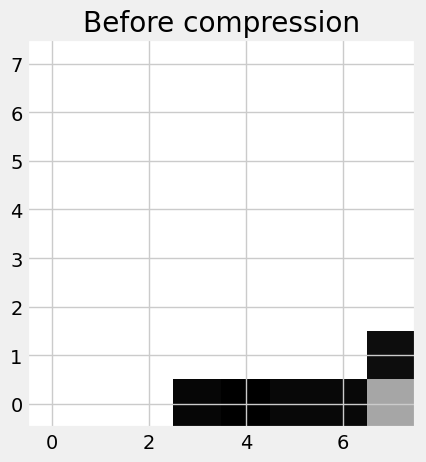

After compression
Shape: (1, 8, 8)


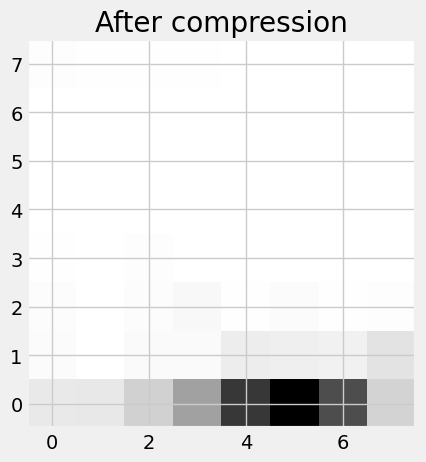

Epoch 2/80: 100%|██████████| 199/199 [00:00<00:00, 524.57it/s, Loss=0.0587]


Epoch [2/80]Average Loss: BCE = 0.0451, MSE = 0.0042843197275832965
Average validation set BCE loss: 0.8254956603050232


Epoch 3/80: 100%|██████████| 199/199 [00:00<00:00, 536.69it/s, Loss=0.0415]


Epoch [3/80]Average Loss: BCE = 0.0425, MSE = 0.0038998672181749764
Average validation set BCE loss: 0.6461099183559418


Epoch 4/80: 100%|██████████| 199/199 [00:00<00:00, 531.31it/s, Loss=0.0514]


...

Epoch [9/80]Average Loss: BCE = 0.0384, MSE = 0.0032968259365040455
Average validation set BCE loss: 0.515360836982727


Epoch 10/80: 100%|██████████| 199/199 [00:00<00:00, 522.92it/s, Loss=0.024] 


Epoch [10/80]Average Loss: BCE = 0.0379, MSE = 0.0032006085876038477
Average validation set BCE loss: 0.47381412863731387


Epoch 11/80: 100%|██████████| 199/199 [00:00<00:00, 545.11it/s, Loss=0.0436]


Epoch [11/80]Average Loss: BCE = 0.0376, MSE = 0.00312677150634328
Average validation set BCE loss: 0.5095907509326935
Last validation batch patch codebook dimensions:
torch.Size([128, 16])
Before compression
Shape: (64, 8, 8)


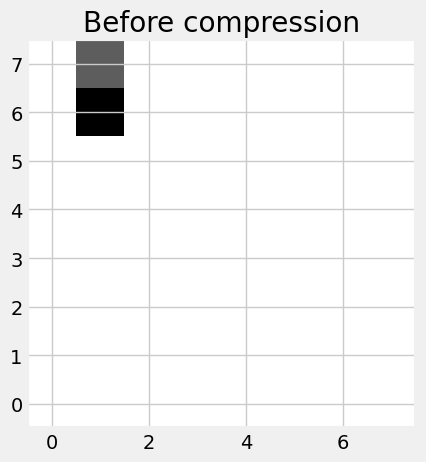

After compression
Shape: (1, 8, 8)


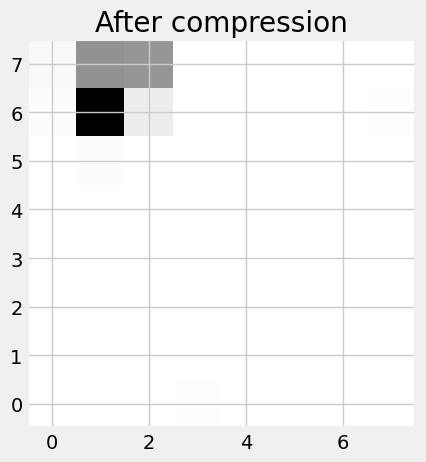

Epoch 12/80: 100%|██████████| 199/199 [00:00<00:00, 533.66it/s, Loss=0.0332]


Epoch [12/80]Average Loss: BCE = 0.0374, MSE = 0.003102024318650365
Average validation set BCE loss: 0.524457471370697


Epoch 13/80: 100%|██████████| 199/199 [00:00<00:00, 538.70it/s, Loss=0.031] 


Epoch [13/80]Average Loss: BCE = 0.0371, MSE = 0.0030353495022796806
Average validation set BCE loss: 0.4933871841430664


Epoch 14/80: 100%|██████████| 199/199 [00:00<00:00, 542.14it/s, Loss=0.0354]


...

Epoch [19/80]Average Loss: BCE = 0.0362, MSE = 0.0028572432748299446
Average validation set BCE loss: 0.46483381152153014


Epoch 20/80: 100%|██████████| 199/199 [00:00<00:00, 533.47it/s, Loss=0.033] 


Epoch [20/80]Average Loss: BCE = 0.0362, MSE = 0.0028741813788948647
Average validation set BCE loss: 0.4704136061668396


Epoch 21/80: 100%|██████████| 199/199 [00:00<00:00, 544.40it/s, Loss=0.03]  


Epoch [21/80]Average Loss: BCE = 0.0360, MSE = 0.002830135254610573
Average validation set BCE loss: 0.5276225364208221
Last validation batch patch codebook dimensions:
torch.Size([128, 16])
Before compression
Shape: (64, 8, 8)


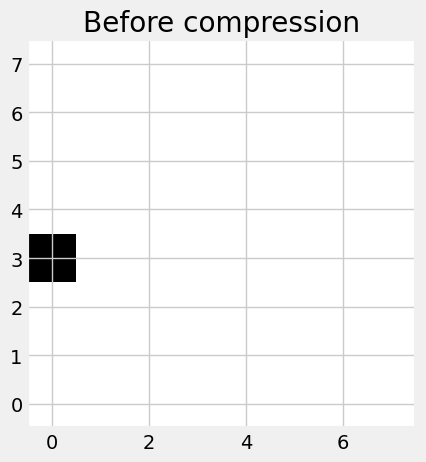

After compression
Shape: (1, 8, 8)


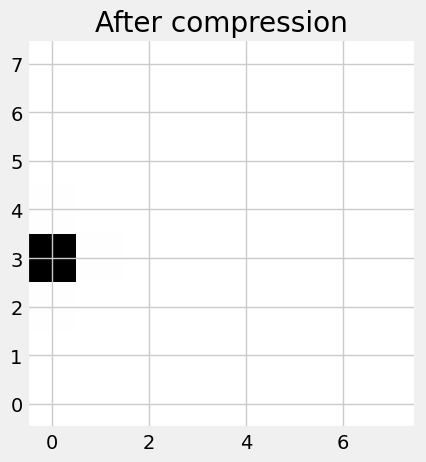

Epoch 22/80: 100%|██████████| 199/199 [00:00<00:00, 526.88it/s, Loss=0.0348]


Epoch [22/80]Average Loss: BCE = 0.0359, MSE = 0.0028024365313482195
Average validation set BCE loss: 0.4507085680961609


Epoch 23/80: 100%|██████████| 199/199 [00:00<00:00, 538.66it/s, Loss=0.0334]


Epoch [23/80]Average Loss: BCE = 0.0357, MSE = 0.0027647725699572407
Average validation set BCE loss: 0.46310556173324585


Epoch 24/80: 100%|██████████| 199/199 [00:00<00:00, 536.67it/s, Loss=0.0383]


...

Epoch [29/80]Average Loss: BCE = 0.0352, MSE = 0.0026347350660271608
Average validation set BCE loss: 0.44068357706069944


Epoch 30/80: 100%|██████████| 199/199 [00:00<00:00, 514.82it/s, Loss=0.0402]


Epoch [30/80]Average Loss: BCE = 0.0353, MSE = 0.0026385108320201613
Average validation set BCE loss: 0.43058162212371826


Epoch 31/80: 100%|██████████| 199/199 [00:00<00:00, 515.12it/s, Loss=0.0455]


Epoch [31/80]Average Loss: BCE = 0.0352, MSE = 0.002605943424608465
Average validation set BCE loss: 0.4304088711738586
Last validation batch patch codebook dimensions:
torch.Size([128, 16])
Before compression
Shape: (64, 8, 8)


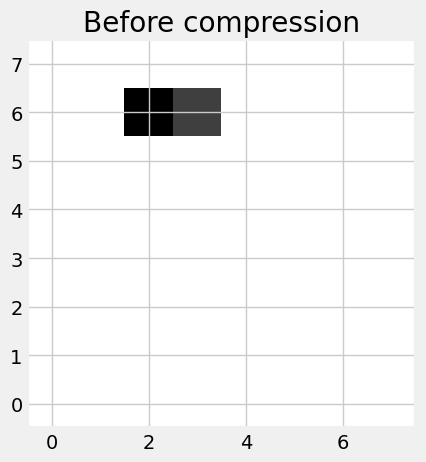

After compression
Shape: (1, 8, 8)


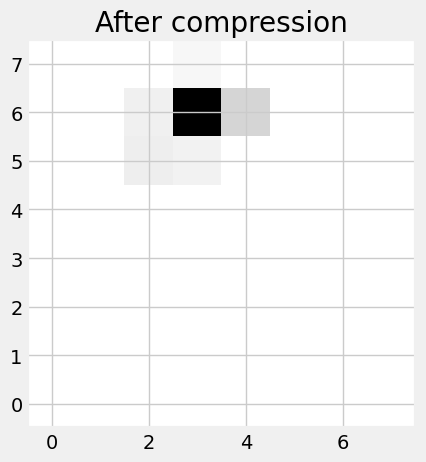

Epoch 32/80: 100%|██████████| 199/199 [00:00<00:00, 512.74it/s, Loss=0.025] 


Epoch [32/80]Average Loss: BCE = 0.0351, MSE = 0.002596195849786564
Average validation set BCE loss: 0.4603733992576599


Epoch 33/80: 100%|██████████| 199/199 [00:00<00:00, 520.38it/s, Loss=0.0304]


Epoch [33/80]Average Loss: BCE = 0.0350, MSE = 0.002561637346080537
Average validation set BCE loss: 0.4860391438007355


Epoch 34/80: 100%|██████████| 199/199 [00:00<00:00, 517.54it/s, Loss=0.0258]


...

Epoch [39/80]Average Loss: BCE = 0.0348, MSE = 0.0024982057652206875
Average validation set BCE loss: 0.43063197016716004


Epoch 40/80: 100%|██████████| 199/199 [00:00<00:00, 531.57it/s, Loss=0.0254]


Epoch [40/80]Average Loss: BCE = 0.0348, MSE = 0.0025091459401344984
Average validation set BCE loss: 0.4158175039291382


Epoch 41/80: 100%|██████████| 199/199 [00:00<00:00, 531.39it/s, Loss=0.0275]


Epoch [41/80]Average Loss: BCE = 0.0347, MSE = 0.002469567123369955
Average validation set BCE loss: 0.45858542919158934
Last validation batch patch codebook dimensions:
torch.Size([128, 16])
Before compression
Shape: (64, 8, 8)


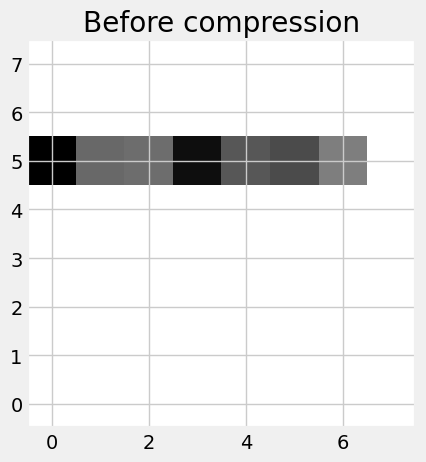

After compression
Shape: (1, 8, 8)


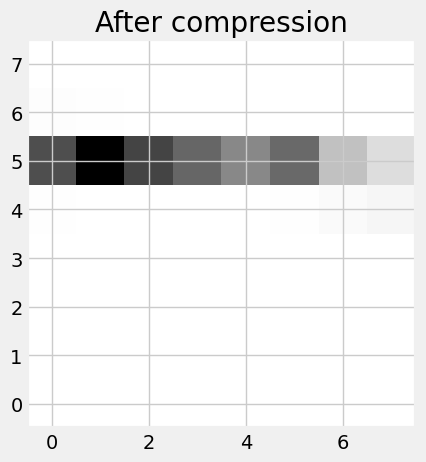

Epoch 42/80: 100%|██████████| 199/199 [00:00<00:00, 522.58it/s, Loss=0.0376]


Epoch [42/80]Average Loss: BCE = 0.0346, MSE = 0.002470736119816613
Average validation set BCE loss: 0.4281196904182434


Epoch 43/80: 100%|██████████| 199/199 [00:00<00:00, 532.75it/s, Loss=0.038] 


Epoch [43/80]Average Loss: BCE = 0.0347, MSE = 0.0024665479265134687
Average validation set BCE loss: 0.4512883448600769


Epoch 44/80: 100%|██████████| 199/199 [00:00<00:00, 519.47it/s, Loss=0.0296]


...

Epoch [49/80]Average Loss: BCE = 0.0346, MSE = 0.002444592980789629
Average validation set BCE loss: 0.4543247163295746


Epoch 50/80: 100%|██████████| 199/199 [00:00<00:00, 515.71it/s, Loss=0.0316]


Epoch [50/80]Average Loss: BCE = 0.0346, MSE = 0.002447187200296277
Average validation set BCE loss: 0.42711177468299866


Epoch 51/80: 100%|██████████| 199/199 [00:00<00:00, 534.00it/s, Loss=0.0256]


Epoch [51/80]Average Loss: BCE = 0.0345, MSE = 0.0024446105986983334
Average validation set BCE loss: 0.43615447521209716
Last validation batch patch codebook dimensions:
torch.Size([128, 16])
Before compression
Shape: (64, 8, 8)


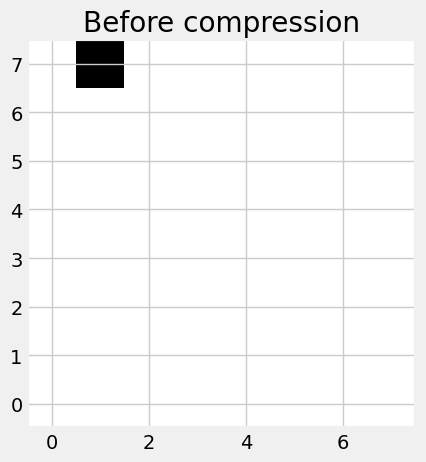

After compression
Shape: (1, 8, 8)


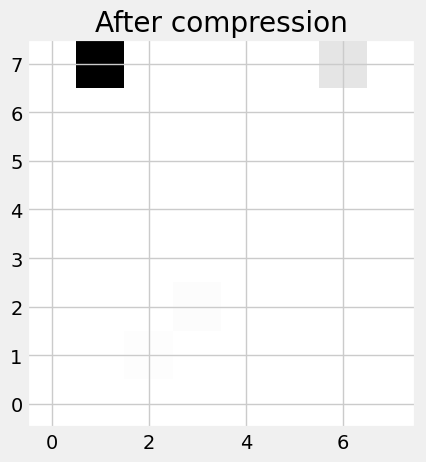

Epoch 52/80: 100%|██████████| 199/199 [00:00<00:00, 516.91it/s, Loss=0.03]  


Epoch [52/80]Average Loss: BCE = 0.0345, MSE = 0.002417220539839274
Average validation set BCE loss: 0.4210666596889496


Epoch 53/80: 100%|██████████| 199/199 [00:00<00:00, 523.81it/s, Loss=0.031] 


Epoch [53/80]Average Loss: BCE = 0.0345, MSE = 0.0024205577640499377
Average validation set BCE loss: 0.41902633249759674


Epoch 54/80: 100%|██████████| 199/199 [00:00<00:00, 528.18it/s, Loss=0.0411]


...

Epoch [59/80]Average Loss: BCE = 0.0344, MSE = 0.0023878116550242255
Average validation set BCE loss: 0.4485548233985901


Epoch 60/80: 100%|██████████| 199/199 [00:00<00:00, 536.82it/s, Loss=0.0212]


Epoch [60/80]Average Loss: BCE = 0.0343, MSE = 0.002368693864183622
Average validation set BCE loss: 0.43313645958900454


Epoch 61/80: 100%|██████████| 199/199 [00:00<00:00, 532.58it/s, Loss=0.025] 


Epoch [61/80]Average Loss: BCE = 0.0343, MSE = 0.002356706270784252
Average validation set BCE loss: 0.4478693771362305
Last validation batch patch codebook dimensions:
torch.Size([128, 16])
Before compression
Shape: (64, 8, 8)


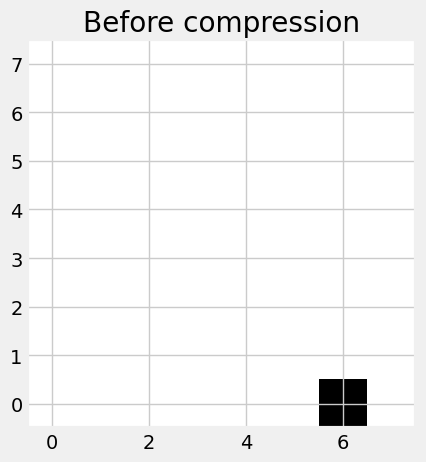

After compression
Shape: (1, 8, 8)


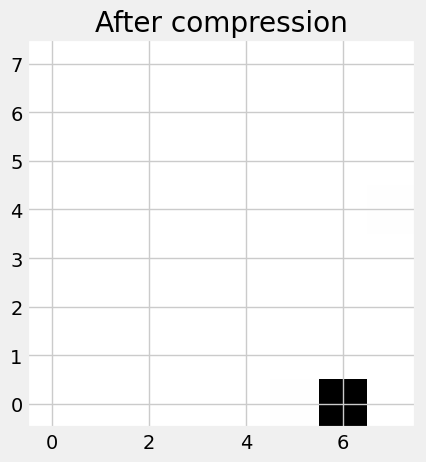

Epoch 62/80: 100%|██████████| 199/199 [00:00<00:00, 534.63it/s, Loss=0.0363]


Epoch [62/80]Average Loss: BCE = 0.0344, MSE = 0.0023630313457097467
Average validation set BCE loss: 0.4173177456855774


Epoch 63/80: 100%|██████████| 199/199 [00:00<00:00, 533.07it/s, Loss=0.0249]


Epoch [63/80]Average Loss: BCE = 0.0342, MSE = 0.002335434764899763
Average validation set BCE loss: 0.42290459156036375


Epoch 64/80: 100%|██████████| 199/199 [00:00<00:00, 529.17it/s, Loss=0.0411]


...

Epoch [69/80]Average Loss: BCE = 0.0342, MSE = 0.002304199827956644
Average validation set BCE loss: 0.41518557906150816


Epoch 70/80: 100%|██████████| 199/199 [00:00<00:00, 528.08it/s, Loss=0.0565]


Epoch [70/80]Average Loss: BCE = 0.0344, MSE = 0.002335905163530167
Average validation set BCE loss: 0.4219998109340668


Epoch 71/80: 100%|██████████| 199/199 [00:00<00:00, 521.74it/s, Loss=0.0484]


Epoch [71/80]Average Loss: BCE = 0.0343, MSE = 0.002322151815289416
Average validation set BCE loss: 0.41307760775089264
Last validation batch patch codebook dimensions:
torch.Size([128, 16])
Before compression
Shape: (64, 8, 8)


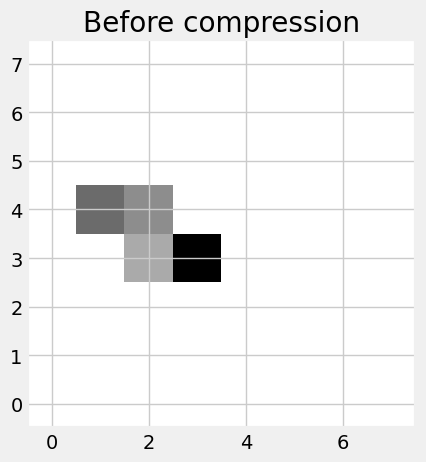

After compression
Shape: (1, 8, 8)


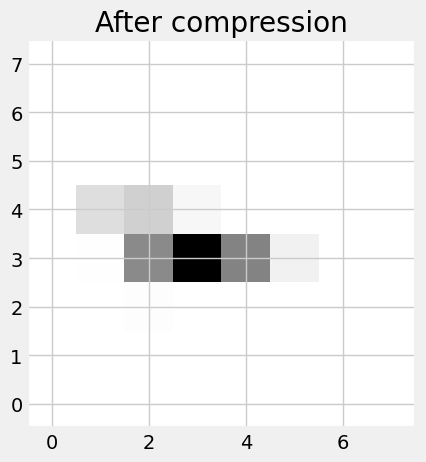

Epoch 72/80: 100%|██████████| 199/199 [00:00<00:00, 518.63it/s, Loss=0.0279]


Epoch [72/80]Average Loss: BCE = 0.0340, MSE = 0.0022661721540951922
Average validation set BCE loss: 0.4267366218566895


Epoch 73/80: 100%|██████████| 199/199 [00:00<00:00, 535.94it/s, Loss=0.0234]


Epoch [73/80]Average Loss: BCE = 0.0342, MSE = 0.002291722637928798
Average validation set BCE loss: 0.4174154543876648


Epoch 74/80: 100%|██████████| 199/199 [00:00<00:00, 544.13it/s, Loss=0.0293]


...

Epoch [78/80]Average Loss: BCE = 0.0340, MSE = 0.0022608343998541183
Average validation set BCE loss: 0.43226709961891174


Epoch 79/80: 100%|██████████| 199/199 [00:00<00:00, 517.42it/s, Loss=0.0328]


Epoch [79/80]Average Loss: BCE = 0.0341, MSE = 0.002248158466641852
Average validation set BCE loss: 0.4062232506275177


Epoch 80/80: 100%|██████████| 199/199 [00:00<00:00, 511.05it/s, Loss=0.0308]


Epoch [80/80]Average Loss: BCE = 0.0341, MSE = 0.002246600231764155
Average validation set BCE loss: 0.41047603011131284
Saving trained model VAE


In [121]:
# BCE loss average values
average_loss_train = []
average_loss_values_val = []
average_loss_kl_loss = []

# Patches
patches_before = []
patches_after = []
patches_z = [] # latent vector

# MSE residual averages
average_loss_train_mse = []
average_loss_valid_mse = []

plot_val_patches_limit = 30
plot_idx = 0

model.train()

for epoch in range(num_epochs):
    train_loss = 0
    train_loss_mse = 0
    kl_loss_total = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        X_adcs = X_adcs.to(device)
        
        (
            recon_patch, 
            _,
            _,
            _
        ) = model(
           X_adcs
        )
        
        loss = _get_vae_loss(recon_patch, X_adcs)
        
        recon_patch = recon_patch.float().to(device)      
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
        
        train_loss += loss.item()
        
        train_loss_mse += mse(recon_patch, X_adcs).item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss': loss.item()})
        # scheduler.step()
        
        
    avg_loss_bce = train_loss / len(train_loader)
    avg_loss_mse = train_loss_mse / len(train_loader)
    
    print(
        f"Epoch [{epoch + 1}/{num_epochs}]"
        f"Average Loss: BCE = {avg_loss_bce:.4f}, "
        f"MSE = {avg_loss_mse}" 
    )
    
    average_loss_train.append(avg_loss_bce)
    average_loss_train_mse.append(avg_loss_mse)
    
    # Test with validation set for checking error residuals
    with torch.no_grad():
        model.eval()
        total_bce_loss = 0
        total_mse_loss = 0
        
        for patch_val in val_loader:
            patch_val = patch_val.to(device)  
            
            (
               recon_patch, 
               codebook, 
               z_q,
               perplexity
            ) = model(patch_val)
            
            total_bce_loss += F.binary_cross_entropy(
                patch_val,
                recon_patch,
                reduction="mean"
            ).cpu().detach().numpy().item()
            
            total_mse_loss += mse(
               patch_val,
               recon_patch  
            ).item()
            
            # result = _get_compression_ratio_vae(
            #     total_hit_amount, 
            #     patch_amount,
            #     z
            # )
        
        average_loss_val = total_bce_loss / len(val_loader)
        average_loss_val_mse = total_mse_loss / len(val_loader)
        average_loss_values_val.append(average_loss_val)
        
        print(f"Average validation set BCE loss: {average_loss_val}")
        # print("Last batch patch, compression metrics:")
        # for k, v in result.items():
        #     print(f"{k} = {v}")
    
        # Test with validation set for checking image reconstruction quality
    
        if epoch % LOG_EVERY == 0:
                # selecting events before reconstruction using one test loader as validation
                
                patches_pairs = []
                
                for patch_val in val_loader:
                    patch_val = patch_val.to(device)           
                    
                    (
                        recon_patch, 
                        codebook, 
                        z_q, 
                        perplexity
                    ) = model(patch_val)
                    
                    if len(patches_pairs) < plot_val_patches_limit:
                        patches_pairs.append((patch_val, z_q, recon_patch))
                
                print("Last validation batch patch codebook dimensions:")
                print(codebook.shape)
                # print(
                #     f"mu: mean={mu.mean().item():.4f}, std={mu.std().item():.4f} | "
                #     f"logvar: mean={logvar.mean().item():.4f}, std={logvar.std().item():.4f}"
                # )
                # print("Loss statistics:")
                # print(
                #     f"recon={recon_loss.item():.4f}, "
                #     f"kl={kl_loss.item():.4f}, " if beta > 0 else ""
                #     f"beta_kl={(beta * kl_loss).item():.4f}" if beta > 0 else ""
                # )
                
                if plot_idx < len(patches_pairs):
                    patch_val_before, z_q, patch_val_after = patches_pairs[plot_idx]
                    
                    print("Before compression")                    
                    patch_val_ts = _tensor_to_numpy(
                        patch_val_before.squeeze(1)
                    )
                    
                    print(f"Shape: {patch_val_ts.shape}")            
                    plot_patch(patch_val_ts[0], "Before compression")
                    
                    patches_before.append(patch_val_ts[0])
                    
                    recon_patch_np = _tensor_to_numpy(
                        patch_val_after[0]
                    )
                    print("After compression")
                    print(f"Shape: {recon_patch_np.shape}")
                    
                    plot_patch(recon_patch_np[0], "After compression")
                
                    patches_after.append(recon_patch_np[0])  
                    z_np = _tensor_to_numpy(z_q[0][0])
                    patches_z.append(z_np) 
                    
                    plot_idx += 1        
            
# save model
print("Saving trained model VAE")
torch.save(model.state_dict(), "vae.pth")

In [122]:
# mu_values = mu.detach().cpu().flatten().numpy()
# # histogram
# plt.hist(mu_values, bins=50)

# plt.title("VAE Latent Mean Distribution")
# plt.xlabel("mu")
# plt.ylabel("count")

# plt.show()

In [123]:
# logvar_values = logvar.detach().cpu().flatten().numpy()
# # histogram
# plt.hist(logvar_values, bins=50)

# plt.title("VAE Latent logvar Distribution")
# plt.xlabel("logvar")
# plt.ylabel("count")

# plt.show()

In [124]:
# TODO
# Compression ratio calculation
# Find total sum of hit bits
# Find total sum of encoded patch bits

total_bits = _get_total_hit_bits(total_hit_amount)


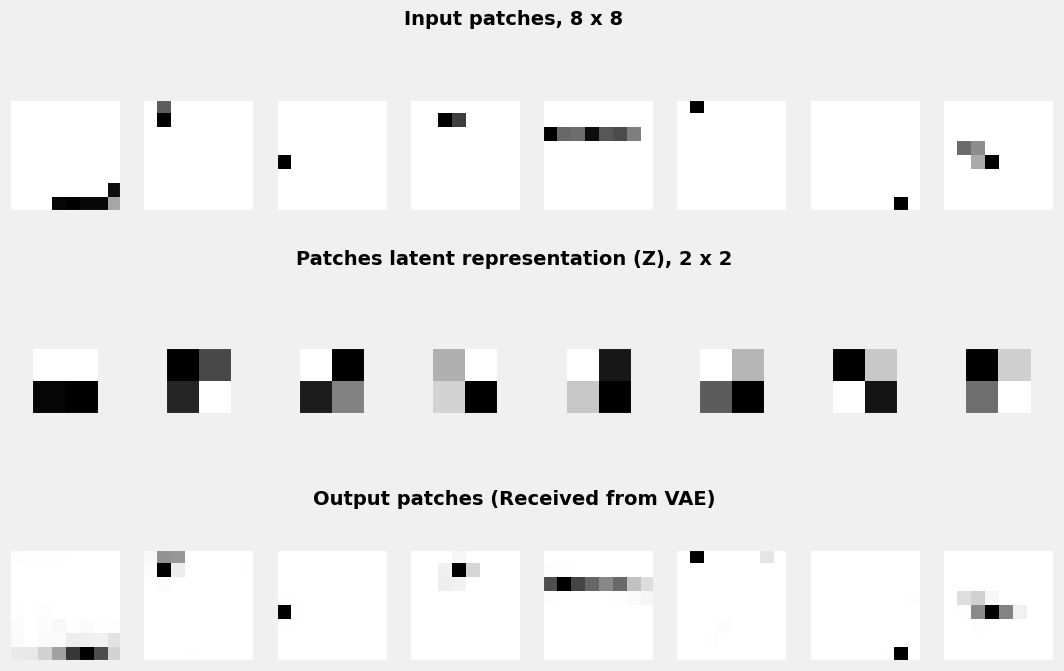

In [125]:
def plot_patches(patch_rows: list[tuple]) -> None:
    cols = len(patch_rows[0][0])
    rows = len(patch_rows)

    # fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
    fig = plt.figure(figsize=(12, 8))
    gs = GridSpec(
        3, cols,
        height_ratios=[1.5, 0.5, 1.5]
    )

    for i in range(rows):
        
        (patch_row, patch_row_title) = patch_rows[i]
        
        fig.text(
            0.5,                    # centered horizontally
            0.92 - i * 0.30,        # vertical position
            patch_row_title,
            ha='center',
            fontsize=14,
            fontweight='bold'
        )
        
        for j in range(cols):
            ax = fig.add_subplot(gs[i, j])
            
            ax.imshow(patch_row[j], cmap='gist_yarg', origin='lower')
            
            ax.set_xticks([])
            ax.set_yticks([])
            
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(1.5)

        plt.subplots_adjust(wspace=0.2, hspace=0.6)
    plt.show()
        
        
patch_rows = [
    (patches_before, "Input patches, 8 x 8"),
    (patches_z, "Patches latent representation (Z), 2 x 2"),
    (patches_after, "Output patches (Received from VAE)")
]

plot_patches(patch_rows)

In [126]:
len(patch_rows[0][0])

8

In [127]:
# TODO
# Improve gradients
_display_gradients(model)

Showing model gradients
encoder.0.weight 4.052593231201172
encoder.1.weight 0.48810943961143494
encoder.1.bias 1.3578778505325317
encoder.3.weight 1.5417245626449585
encoder.4.weight 0.40869930386543274
encoder.4.bias 0.3501254916191101
encoder.6.weight 1.9541550874710083
encoder.7.weight 0.07730258256196976
encoder.7.bias 0.056133050471544266
decoder.0.weight 0.003512223018333316
decoder.1.weight 0.0002051615883829072
decoder.1.bias 0.00035810694680549204
decoder.3.weight 0.0015570583054795861
decoder.4.weight 5.831627640873194e-05
decoder.4.bias 0.00010643759742379189
decoder.6.weight 0.0005925044533796608


/tmp/ipykernel_392025/3472732.py:79: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


VQ VAE, Average loss values over epochs


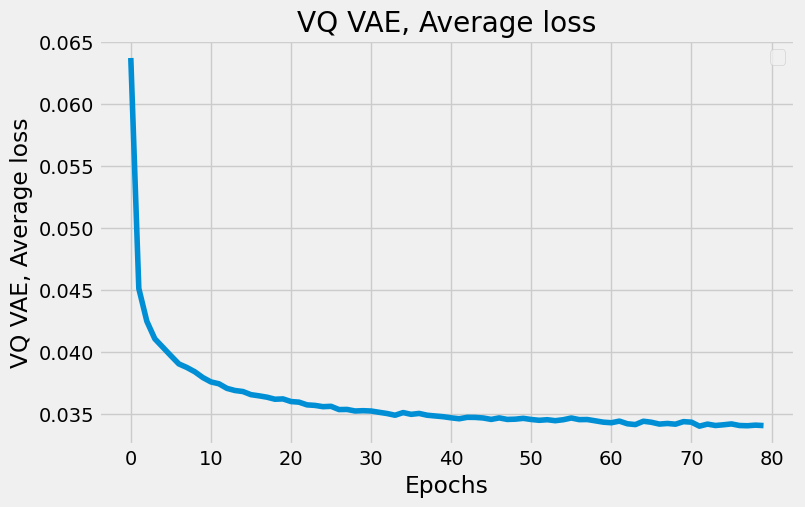

In [128]:
# display loss values
plot_metric_results(
    y_values=average_loss_train, 
    x_values=list(range(num_epochs)),
    y_title="VQ VAE, Average loss",
    title="VQ VAE, Average loss",
    x_label="Epochs"
)

In [129]:
# print(f"mu = {model.z_log_mean.mean().item()}")
# print(f"logvar = {model.z_log_var.std().item()}")

In [130]:
# Test set for testing using unseen data
model.load_state_dict(torch.load("vae.pth"))
model.eval()

bce_loss_values_test = []

patch_display_limit = 8
patches_after_test = []
patches_before_test = []
patches_z = [] # latent vector

bce_total_value = 0

test_set_size = len(test_loader)

for patch_test in test_loader:
    patch_test = patch_test.to(device)                     
    (
        recon_patch, 
        codebook, 
        z_q, 
        perplexity
    ) = model(patch_test)
    
    if len(patches_after_test) < patch_display_limit:
        patch_test_np = patch_test[0][0].cpu().detach().numpy()
        patches_before_test.append(patch_test_np)
        
        recon_patch_np = recon_patch[0][0].cpu().detach().numpy()
        patches_after_test.append(recon_patch_np)
        z_np = _tensor_to_numpy(z_q[0][0])
        
        patches_z.append(z_np)
    
    # mse_loss = F.mse_loss(patch_test, recon_patch).item()
    bce_loss = F.binary_cross_entropy(
        patch_test, 
        recon_patch, 
        reduction="sum"
    ).cpu().detach().numpy().item()
    
    bce_total_value += bce_loss
    
bce_loss_average = bce_total_value / test_set_size

print(f"Based on test set (size = {test_set_size}), average BCE loss = {bce_loss_average:.5f}")

Based on test set (size = 25), average BCE loss = 1669.17494


In [131]:
len(patches_before_test)

8

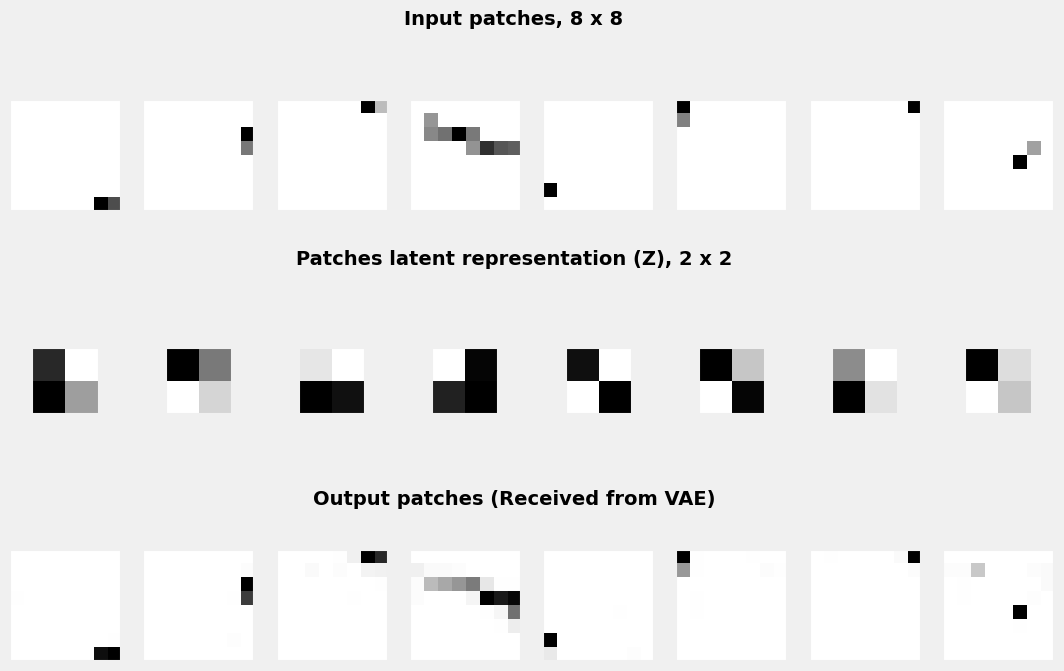

In [132]:
# Test dataset plotting part
patch_rows = [
    (patches_before_test, "Input patches, 8 x 8"),
    (patches_z, "Patches latent representation (Z), 2 x 2"),
    (patches_after_test, "Output patches (Received from VAE)")
]

plot_patches(patch_rows)

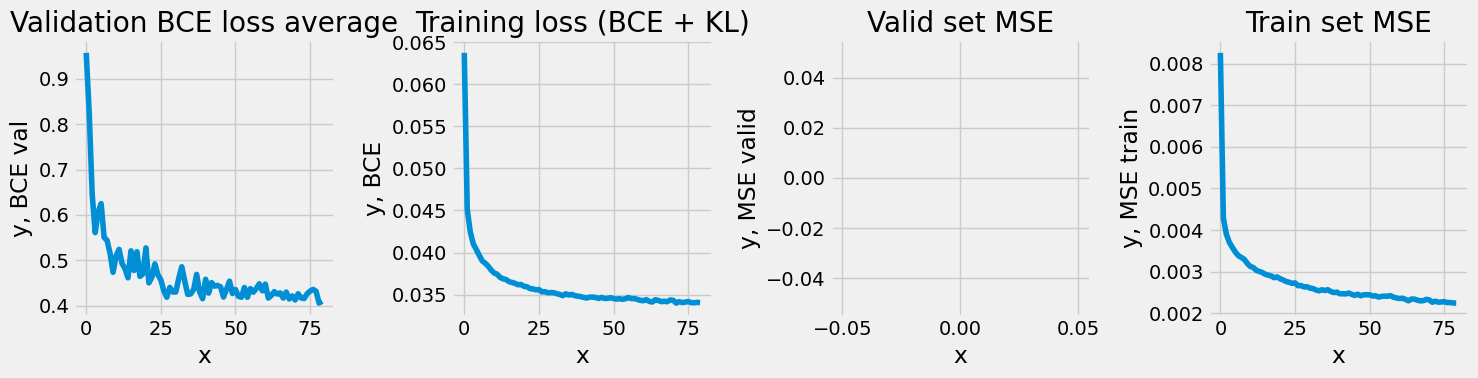

In [133]:
values_to_plot = [
    (list(range(len(average_loss_values_val))), average_loss_values_val, "Validation BCE loss average", "BCE val"),
    (list(range(len(average_loss_train))), average_loss_train, "Training loss (BCE + KL)", "BCE"),
    (list(range(len(average_loss_valid_mse))), average_loss_valid_mse, "Valid set MSE", "MSE valid"),
    (list(range(len(average_loss_train_mse))), average_loss_train_mse, "Train set MSE", "MSE train"),
]

fig, axes = plt.subplots(1, len(values_to_plot), figsize=(15, 4))

for i, (x, y, title, y_label) in enumerate(values_to_plot):
    axes[i].plot(
        x,
        y,
    )
    axes[i].grid(True)
    axes[i].set_title(title)
    axes[i].set_xlabel("x")
    axes[i].set_ylabel(f"y, {y_label}")
    
    for spine in axes[i].spines.values():
        spine.set_linewidth(2)

plt.tight_layout()
plt.show()

# print(title + " values over epochs")
# plt.style.use('fivethirtyeight')
# plt.figure(figsize=(8, 5))
# plt.plot(x_values, y_values, marker=marker)
# plt.xlabel(x_label)
# plt.ylabel(y_title)
# plt.legend()
# plt.title(title)
# plt.show()